# Análisis de Emisiones de Gases de Efecto Invernadero de Argentina (1990–2022)

**Fuente de datos:** *(completar acá el origen oficial del dataset — ej. Inventario Nacional de Gases de Efecto Invernadero (INGEI), Ministerio de Ambiente de la Nación, y el link de descarga)*

## Índice

1. [Objetivo general](#objetivo-general)
2. [Pregunta principal](#pregunta-principal)
3. [Preguntas secundarias](#preguntas-secundarias)
4. [Resumen ejecutivo](#resumen-ejecutivo)
5. [Carga de dataset](#carga-de-dataset)
6. [Auditoría general del dataset](#auditoría-general-del-dataset)
7. [Limpieza y transformación](#limpieza-y-transformación)
8. [Agregación por sector y evolución temporal](#agregación-por-sector-y-evolución-temporal)
9. [Composición por tipo de gas](#composición-por-tipo-de-gas)
10. [Principales actividades dentro de los sectores con mayor contribución](#principales-actividades-dentro-de-los-sectores-con-mayor-contribución)
11. [Principales categorías emisoras en los últimos años](#principales-categorías-emisoras-en-los-últimos-años)
12. [Conclusiones generales](#conclusiones-generales)
13. [Exportación del dataset limpio](#exportación-del-dataset-limpio)

## Objetivo general

Analizar la evolución de las emisiones de gases de efecto invernadero en Argentina entre 1990 y 2022, identificando los principales sectores, actividades y gases responsables de las emisiones y evaluando la evolución de las remociones asociadas al uso de la tierra.

## Pregunta principal

¿Cómo evolucionaron las emisiones de GEI de Argentina entre 1990 y 2022 y qué sectores y actividades explican los principales cambios?

## Preguntas secundarias
* ¿Cómo evolucionaron las emisiones totales entre 1990 y 2022?
* ¿Cuáles son los sectores con mayor contribución?
* ¿Qué actividades explican las emisiones dentro de cada sector?
* ¿Cuáles son las principales categorías emisoras?
* ¿Qué gases tienen mayor participación?
* ¿Cómo cambió la composición de las emisiones a través del tiempo?
* ¿Qué sectores aumentaron o disminuyeron más entre 1990 y 2022?
* ¿Cuáles son las principales fuentes de emisiones en los últimos años?
* ¿Qué cambios relevantes pueden identificarse desde una perspectiva de gestión ambiental?

## Resumen ejecutivo

*(Sección escrita al final del análisis, a modo de síntesis para una lectura rápida. El detalle y la justificación de cada punto están en las secciones correspondientes más abajo.)*

* El dataset original tiene 7.778 registros (1990–2022); tras eliminar 41 duplicados exactos quedaron 7.737 registros limpios, sin valores nulos.
* El balance total de emisiones/remociones de GEI de Argentina muestra una **tendencia creciente** entre 1990 y 2022, con fluctuaciones año a año.
* **Energía** y **Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra** son, por lejos, los dos sectores que más pesan en el balance acumulado del período, muy por encima de Procesos industriales y Residuos.
* **Energía** es el sector que más creció en términos absolutos, impulsado casi enteramente por las actividades de quema de combustible. **Agricultura/Ganadería/Silvicultura**, pese a ser el de mayor volumen acumulado, fue el más estable en el tiempo — dentro de él, Ganadería y los cambios de uso de la tierra explican la mayor parte del total.
* El **CO₂** es el gas dominante (~60 % del balance total), seguido por **CH₄** (~34 %) y **N₂O** (~5 %). La composición cambió en el tiempo: el CO₂ ganó participación relativa y el CH₄ la perdió, y los HFC (gases sintéticos) aparecen recién en las últimas décadas.
* Los 144 registros con valores negativos no son errores: son remociones de CO₂ asociadas a tierras forestales, pastizales y productos de madera, y se conservaron en el dataset diferenciadas mediante la variable `tipo_de_registro`.
* En los últimos 5 años (2018–2022), "Bovinos de Carne", "Transporte terrestre por carretera" y "Producción pública de electricidad y calor" son las categorías individuales que más aportaron al balance.

## Carga de dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(
    "E:\\PROYECTOS PYTHON\\proyecto-GEI\\data\\raw\\emisiones_datos_totales_1990_2022.csv",
    sep=";"
)

## Auditoría general del dataset

Se verificó la presencia de valores nulos en las ocho variables
del dataset. No se identificaron valores faltantes, por lo que
no es necesario aplicar estrategias de imputación o eliminación
de registros por este motivo.

### Dimensiones

In [3]:
# Dimensiones

df.shape

(7778, 8)

### Nombre de las variables

In [4]:
# Columnas

df.columns

Index(['año', 'sector', 'actividad', 'subactividad', 'categoria', 'id_ipcc',
       'tipo_de_gas', 'valor_en_toneladas_de_co2e'],
      dtype='object')

### Primeros registros

In [5]:
# Primeras observaciones

df.head()

,año,sector,actividad,subactividad,categoria,id_ipcc,tipo_de_gas,valor_en_toneladas_de_co2e
0,1990,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,15.33
1,1991,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,18.78
2,1992,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,17.54
3,1993,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,17.11
4,1994,Energía,Actividades de quema de combustible,Industrias de la energía,Producción pública de electricidad y calor,1A1a,CO2,16.03


### Últimos registros

In [6]:
df.tail()

,año,sector,actividad,subactividad,categoria,id_ipcc,tipo_de_gas,valor_en_toneladas_de_co2e
7773,2018,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.80
7774,2019,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.81
7775,2020,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.76
7776,2021,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.80
7777,2022,Residuos,Aguas Residuales,Aguas residuales Industriales,Aguas residuales Industriales: Alimentos y Beb...,5D2e,CH4,0.84


### Estructura y tipo de datos

In [7]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7778 entries, 0 to 7777
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   año                         7778 non-null   int64  
 1   sector                      7778 non-null   object 
 2   actividad                   7778 non-null   object 
 3   subactividad                7778 non-null   object 
 4   categoria                   7778 non-null   object 
 5   id_ipcc                     7778 non-null   object 
 6   tipo_de_gas                 7778 non-null   object 
 7   valor_en_toneladas_de_co2e  7778 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 486.3+ KB


### Valores nulos

In [8]:
# Valores faltantes

df.isnull().sum()

año                           0
sector                        0
actividad                     0
subactividad                  0
categoria                     0
id_ipcc                       0
tipo_de_gas                   0
valor_en_toneladas_de_co2e    0
dtype: int64

### Registros duplicados

In [9]:
# Observamos que existen 41 registros duplicados, por lo que es necesario hacer una revisión para ver si son realmente duplicados o corresponden a observaciones válidas que coinciden en sus valores
df.duplicated().sum()

np.int64(41)

Aquí detectamos valores duplicados por lo que es necesario mas adelante realizar una investigación para saber que tratamiento les tenemos que dar

### Distribución de variables categóricas

#### Sector

In [10]:
df["sector"].value_counts()

sector
Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra     3234
Energía                                                            3070
Procesos industriales y uso de productos                           1110
Residuos                                                            364
Name: count, dtype: int64

#### Actividad

In [11]:
df["actividad"].value_counts()

actividad
Actividades de quema de combustible                                    2146
Uso de Suelos                                                          1980
Ganadería                                                               924
Emisiones fugitivas provenientes de la fabricación de combustibles      924
Industria química                                                       396
Tierra                                                                  330
Uso de productos                                                        285
Industria de los metales                                                264
Aguas Residuales                                                        231
Industria de los minerales                                              165
Residuos Sólidos                                                        100
Incineración de residuos                                                 33
Name: count, dtype: int64

#### Subactividad

In [12]:
df["subactividad"].value_counts()

subactividad
Emisiones Fugitivas                                924
Excretas en pasturas                               891
Industrias manufactureras y de la construcción     880
Gestión de Estiércol                               627
Uso de Suelos                                      627
Otros sectores                                     495
Transporte                                         474
Fertilizantes orgánicos                            396
Industrias de la energía                           297
Fermentación Entérica                              297
Producción petroquímica y de negro de humo         264
Usos de Sustitutos de SAO                          219
Tierras Forestales                                 165
Aguas residuales Industriales                      165
Eliminación de residuos sólidos                    100
Otros Industrias de los Metales                     99
Otros Industria de los minerales                    99
Producción de aluminio                              

#### Categoría

In [13]:
df["categoria"].value_counts()

categoria
Otras Ganaderías                                         1551
Fugitivas producción de Gas Natural                       396
Bovinos de Carne                                          363
Fugitivas producción de Petróleo                          330
Comercial/institucional                                   297
                                                         ... 
Aguas residuales Industriales: Refinerías de petróleo      33
Aguas residuales Industriales: Celulosa y Papel            33
Aguas residuales Industriales: Alimentos y Bebidas         33
Producción de ceniza de sosa                               18
Producción fluoroquímica                                   15
Name: count, Length: 68, dtype: int64

#### Tipo de gas

In [14]:
df["tipo_de_gas"].value_counts()

tipo_de_gas
N2O    2912
CH4    2516
CO2    2050
HFC     234
PFC      66
Name: count, dtype: int64

#### Año

In [15]:
# Resgistros totales por año donde observamos que la cantidad de registros por año no es constante, aumentando progresivamente año a año y de aquí surge la siguiente pregunta, ¿por qué aumenta el número de observaciones a medida que avanzan los años?

df["año"].value_counts().sort_index()

año
1990    206
1991    206
1992    206
1993    206
1994    206
1995    228
1996    228
1997    230
1998    230
1999    230
2000    230
2001    230
2002    230
2003    230
2004    230
2005    232
2006    234
2007    235
2008    234
2009    236
2010    243
2011    246
2012    251
2013    252
2014    254
2015    254
2016    254
2017    254
2018    254
2019    254
2020    255
2021    255
2022    255
Name: count, dtype: int64

### Estadística de emisiones

In [16]:
df["valor_en_toneladas_de_co2e"].describe()

count    7778.000000
mean        1.594045
std         7.512023
min       -43.740000
25%         0.000000
50%         0.050000
75%         0.550000
max        77.930000
Name: valor_en_toneladas_de_co2e, dtype: float64

Mirando los valores de esta celda, vemos que tenemos una distribución fuertemente asimétrica, probablemente con muchos valores pequeños/cercanos a cero y un grupo reducido de observaciones bastante grandes.

Esto tiene sentido en un inventario ambiental: no todas las fuentes contribuyen con magnitudes similares. De todas formas todavia no lo vamos a asumir hasta no visualizarlo mas adelante.

### Relación entre variables

In [17]:
# Procedo a generar una tabla que me permita observar qué actividades pertenecen a cada sector
# De esta forma vemoss que no estamos ante una tabla completamente desordenada, se ve una clasificación coherente
pd.crosstab(
    df["sector"],
    df["actividad"]
)

actividad,Actividades de quema de combustible,Aguas Residuales,Emisiones fugitivas provenientes de la fabricación de combustibles,Ganadería,Incineración de residuos,Industria de los metales,Industria de los minerales,Industria química,Residuos Sólidos,Tierra,Uso de Suelos,Uso de productos
sector,,,,,,,,,,,,
"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",0,0,0,924,0,0,0,0,0,330,1980,0
Energía,2146,0,924,0,0,0,0,0,0,0,0,0
Procesos industriales y uso de productos,0,0,0,0,0,264,165,396,0,0,0,285
Residuos,0,231,0,0,33,0,0,0,100,0,0,0


In [18]:
# Hacemos lo mismo pero con la variable tipo_de_gas
pd.crosstab(
    df["sector"],
    df["tipo_de_gas"]
)

tipo_de_gas,CH4,CO2,HFC,N2O,PFC
sector,,,,,
"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",858,363,0,2013,0
Energía,1179,1075,0,816,0
Procesos industriales y uso de productos,198,579,234,33,66
Residuos,281,33,0,50,0


De esta tabla podemos observar lo siguiente, aunque solo estamos hablando de cantidad de registros y no del impacto de las emisiones en total:

* Agricultura tiene una gran cantidad de observaciones de N₂O.
* Energía tiene muchos registros de CH₄ y CO₂.
* Procesos industriales es el sector donde aparecen HFC y PFC.
* Residuos presenta principalmente CH₄.

## Limpieza y transformación

### Análisis de registros duplicados

#### Investigamos la estructura de los duplicados

In [19]:
columnas_clave = [
    "año",
    "sector",
    "actividad",
    "subactividad",
    "categoria",
    "id_ipcc",
    "tipo_de_gas"
]

df.duplicated(subset=columnas_clave).sum()

np.int64(168)

* **Se verificó si existían combinaciones repetidas entre las variables que describen cada registro. Se identificaron 168 repeticiones.**
* **Sin embargo, estas repeticiones no fueron eliminadas automáticamente, ya que podían corresponder a registros con diferentes valores de emisiones.**

In [20]:
df.duplicated().sum()


np.int64(41)

In [21]:
df[df.duplicated(keep=False)].shape

(72, 8)

* **De esta forma estamos mostrando todas las filas que forman parte de los grupos duplicados, incluida la primera aparición. Por eso ahora tenemos 72 duplicados y no 41 como vimos anteriormente**

In [22]:
repetidos = (
    df.groupby(columnas_clave)
      .agg(
          cantidad_registros=("valor_en_toneladas_de_co2e", "size"),
          valores_distintos=("valor_en_toneladas_de_co2e", "nunique"),
          valor_min=("valor_en_toneladas_de_co2e", "min"),
          valor_max=("valor_en_toneladas_de_co2e", "max")
      )
      .query("cantidad_registros > 1")
      .sort_values(
          ["cantidad_registros", "valores_distintos"],
          ascending=False
      )
)

repetidos.head(20)

,,,,,,,cantidad_registros,valores_distintos,valor_min,valor_max
año,sector,actividad,subactividad,categoria,id_ipcc,tipo_de_gas,,,,
2020,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,6,5,0.00,2.06
2021,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,6,5,0.00,2.34
2022,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,6,5,0.00,2.56
2012,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,5,5,0.00,0.27
2013,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,5,5,0.00,0.30
2014,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,5,5,0.00,0.52
2015,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,5,5,0.00,0.89
2016,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,5,5,0.00,1.29
2017,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,5,5,0.00,1.54


#### Investigamos los duplicados exactos

In [23]:
df["es_duplicado_exacto"] = df.duplicated(keep=False)
df["es_duplicado_exacto"].value_counts()

es_duplicado_exacto
False    7706
True       72
Name: count, dtype: int64

In [24]:
df[df["es_duplicado_exacto"]].sort_values(columnas_clave)

,año,sector,actividad,subactividad,categoria,id_ipcc,tipo_de_gas,valor_en_toneladas_de_co2e,es_duplicado_exacto
4022,2011,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.00,True
4024,2011,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.00,True
4025,2011,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F1f,HFC,0.00,True
4084,2012,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F2,HFC,0.00,True
4085,2012,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F2,HFC,0.00,True
...,...,...,...,...,...,...,...,...,...
4114,2022,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F2,HFC,0.00,True
4144,2022,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F3,HFC,0.02,True
4146,2022,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F3,HFC,0.02,True
4178,2022,Procesos industriales y uso de productos,Uso de productos,Usos de Sustitutos de SAO,Usos de productos como sustitutos de las SAO,2F4,HFC,0.00,True


#### Analizamos la frecuencia de estas repeticiones

In [25]:
df[df["es_duplicado_exacto"]].groupby(
    columnas_clave + ["valor_en_toneladas_de_co2e"]
).size().value_counts()

2    21
3    10
Name: count, dtype: int64

#### Eliminamos unicamente las copias exactas

In [26]:
df = df.drop_duplicates()
df.shape

(7737, 9)

In [27]:
print(f'Duplicados: {df.duplicated().sum()}\nFilas/Columnas: {df.shape}')

Duplicados: 0
Filas/Columnas: (7737, 9)


In [28]:
# Dropeamos la columna "es_duplicado_exacto"
df = df.drop(columns="es_duplicado_exacto")

**Limpieza de registros duplicados**

Durante el control de calidad del dataset se identificaron 41 registros duplicados mediante df.duplicated().sum().

Para determinar si estas duplicaciones correspondían efectivamente a errores, se realizó un análisis adicional utilizando las variables descriptivas del dataset. Esta evaluación identificó 168 registros que compartían la misma combinación de año, sector, actividad, subactividad, categoría, código IPCC y tipo de gas. Sin embargo, se comprobó que varias de estas coincidencias presentaban diferentes valores de emisiones, por lo que no podían considerarse duplicados y fueron conservadas.

Posteriormente, se identificaron 72 registros que eran completamente idénticos en todas sus variables. Estos correspondían a 21 grupos con dos registros repetidos y 10 grupos con tres registros repetidos.

Por lo tanto, se eliminaron únicamente las copias exactas mediante drop_duplicates(), conservando una única instancia de cada observación.

Como resultado, el dataset pasó de 7.778 a 7.737 registros, manteniendo las observaciones que presentan diferencias en sus valores de emisiones.

### Análisis de emisiones vs. remociones

In [29]:
valores_negativos = (df["valor_en_toneladas_de_co2e"] < 0).sum()
valores_0 = (df["valor_en_toneladas_de_co2e"] == 0).sum()
valores_positivos = (df["valor_en_toneladas_de_co2e"] > 0).sum()

print(f'Valores negativos: {valores_negativos} --> Emisión de GEI\nValores cero: {valores_0} --> No se registró emisión/remoción para esa observación\nValores positivos: {valores_positivos} --> Remoción/absorción de CO₂')

Valores negativos: 144 --> Emisión de GEI
Valores cero: 1949 --> No se registró emisión/remoción para esa observación
Valores positivos: 5644 --> Remoción/absorción de CO₂


Aquí, encontramos un hallazgo ambiental importante:
* Los 144 valores negativos a primera vista parecen corresponder a remociones, por lo que mas adelante vamos a ver a que acitividad corresponden
* Tenemos 1949 valores que son 0 y se corresponden a mediciones válidas que no son NaN
* Los 5644 registros con valores positivos respecto a emisiones de Gases de Efecto Invernadero

Como conclusion parcial podemos decir que el 1.9 % de los datos corresponden a remociones, el 25.2 % a valores iguales a 0 y el 72.9 % se corresponde a registros de emisiones

#### Analizando las remociones

In [30]:
df[df["valor_en_toneladas_de_co2e"] < 0].head(20)

,año,sector,actividad,subactividad,categoria,id_ipcc,tipo_de_gas,valor_en_toneladas_de_co2e
7117,1990,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.08
7118,1991,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.05
7119,1992,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.06
7120,1993,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.04
7121,1994,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.05
7122,1995,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.06
7123,1996,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.06
7124,1997,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.06
7125,1998,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.11
7126,1999,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,4A1aii,CO2,-4.14


In [31]:
gas_rem = df[df["valor_en_toneladas_de_co2e"] < 0]["tipo_de_gas"].value_counts()
act_rem = df[df["valor_en_toneladas_de_co2e"] < 0]["actividad"].value_counts()
cat_rem = df[df["valor_en_toneladas_de_co2e"] < 0]["categoria"].value_counts()

print(f'VALORES NEGATIVOS:\n{"-"*25}\n{gas_rem}\n{"-"*25}\n{act_rem}\n{"-"*25}\n{cat_rem}')


VALORES NEGATIVOS:
-------------------------
tipo_de_gas
CO2    144
Name: count, dtype: int64
-------------------------
actividad
Tierra     144
Name: count, dtype: int64
-------------------------
categoria
Tierras forestales que permanecen como tales    66
Pastizales convertidos en Tierras de Cultivo    33
Productos de madera recolectada                 33
Tierras de cultivo que permanecen como tales    12
Name: count, dtype: int64


**Esto refuerza mucho nuestra interpretación anterior, por lo que no debemos eliminar los valores negativos.**

**En un inventario de gases de efecto invernadero, un valor negativo de CO₂ puede representar una remoción de carbono de la atmósfera, asociada a determinados usos de la tierra, cambios en la cobertura vegetal y productos de madera.**

#### Incorporación de variable: tipos de registro

In [32]:
#Mediante la incorporación de esta variable, clasificamos los registros en: "Emisión", "Remoción" y "Sin emisión/remoción"
condiciones = [
    df["valor_en_toneladas_de_co2e"] > 0,
    df["valor_en_toneladas_de_co2e"] < 0,
    df["valor_en_toneladas_de_co2e"] == 0
]

categorias = [
    "Emisión",
    "Remoción",
    "Sin emisión/remoción"
]

df["tipo_de_registro"] = np.select(
    condiciones,
    categorias,
    default="Sin clasificar"
) #asigna categoría correspondiente

In [33]:
df["tipo_de_registro"].value_counts()

tipo_de_registro
Emisión                 5644
Sin emisión/remoción    1949
Remoción                 144
Name: count, dtype: int64

In [34]:
#De esta forma comprobamos las cantidades asociadas a cada tipo de registro
pd.crosstab(
    df["tipo_de_registro"],
    df["tipo_de_gas"]
)

tipo_de_gas,CH4,CO2,HFC,N2O,PFC
tipo_de_registro,,,,,
Emisión,1714,1689,138,2054,49
Remoción,0,144,0,0,0
Sin emisión/remoción,802,217,57,856,17


**Clasificación de emisiones y remociones**

El análisis de los valores negativos mostró que los 144 registros con valores inferiores a cero corresponden exclusivamente a emisiones de CO₂ asociadas a la actividad "Tierra". Las observaciones se concentran en categorías relacionadas con tierras forestales, pastizales, tierras de cultivo y productos de madera recolectada.

Debido a estas características, los valores negativos no fueron considerados errores ni eliminados del dataset. En el contexto del inventario, se interpretan como registros asociados a procesos de remoción de CO₂.

Para facilitar el análisis posterior, se creó una nueva variable denominada tipo_de_registro, clasificando las observaciones en tres grupos:

* Emisión: valores positivos de toneladas de CO₂ equivalente.
* Remoción: valores negativos de toneladas de CO₂ equivalente.
* Sin emisión/remoción: valores iguales a cero.

Esta transformación permitirá diferenciar posteriormente las emisiones de las remociones y calcular indicadores como emisiones brutas, remociones y balance neto mediante SQL y Power BI.

In [35]:
# Vemos los valores extremos
df.nlargest(
    10,
    "valor_en_toneladas_de_co2e"
)[
    [
        "año",
        "sector",
        "actividad",
        "subactividad",
        "categoria",
        "tipo_de_gas",
        "valor_en_toneladas_de_co2e"
    ]
]

,año,sector,actividad,subactividad,categoria,tipo_de_gas,valor_en_toneladas_de_co2e
7327,2002,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Pastizales,Tierras forestales convertidas en pastizales,CO2,77.93
7331,2006,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Pastizales,Tierras forestales convertidas en pastizales,CO2,76.29
7333,2008,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Pastizales,Tierras forestales convertidas en pastizales,CO2,76.15
4217,1994,"Agricultura, Ganadería, Silvicultura y Otros U...",Ganadería,Fermentación Entérica,Bovinos de Carne,CH4,74.84
7330,2005,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Pastizales,Tierras forestales convertidas en pastizales,CO2,74.49
7328,2003,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Pastizales,Tierras forestales convertidas en pastizales,CO2,74.34
4216,1993,"Agricultura, Ganadería, Silvicultura y Otros U...",Ganadería,Fermentación Entérica,Bovinos de Carne,CH4,74.32
4218,1995,"Agricultura, Ganadería, Silvicultura y Otros U...",Ganadería,Fermentación Entérica,Bovinos de Carne,CH4,73.40
4231,2008,"Agricultura, Ganadería, Silvicultura y Otros U...",Ganadería,Fermentación Entérica,Bovinos de Carne,CH4,72.50
4215,1992,"Agricultura, Ganadería, Silvicultura y Otros U...",Ganadería,Fermentación Entérica,Bovinos de Carne,CH4,72.42


De aquí extraemos una pista muy interesante y es que el valor máximo de emisiones (77.93 tCO2e) está relacionado con cambios en el uso de la tierra. Pero todavia es muy temprano para concluir que el mayor registro individual corresponde al mayor sector emisor, eso lo vamos a corroborar mas adelante agregando los datos

In [36]:
df.nsmallest(
    10,
    "valor_en_toneladas_de_co2e"
)[
    [
        "año",
        "sector",
        "actividad",
        "subactividad",
        "categoria",
        "tipo_de_gas",
        "valor_en_toneladas_de_co2e"
    ]
]

,año,sector,actividad,subactividad,categoria,tipo_de_gas,valor_en_toneladas_de_co2e
7214,2021,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.74
7208,2015,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.49
7209,2016,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.30
7213,2020,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.24
7207,2014,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.16
7210,2017,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.15
7212,2019,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.10
7211,2018,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-43.00
7206,2013,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-42.61
7205,2012,"Agricultura, Ganadería, Silvicultura y Otros U...",Tierra,Tierras Forestales,Tierras forestales que permanecen como tales,CO2,-42.02


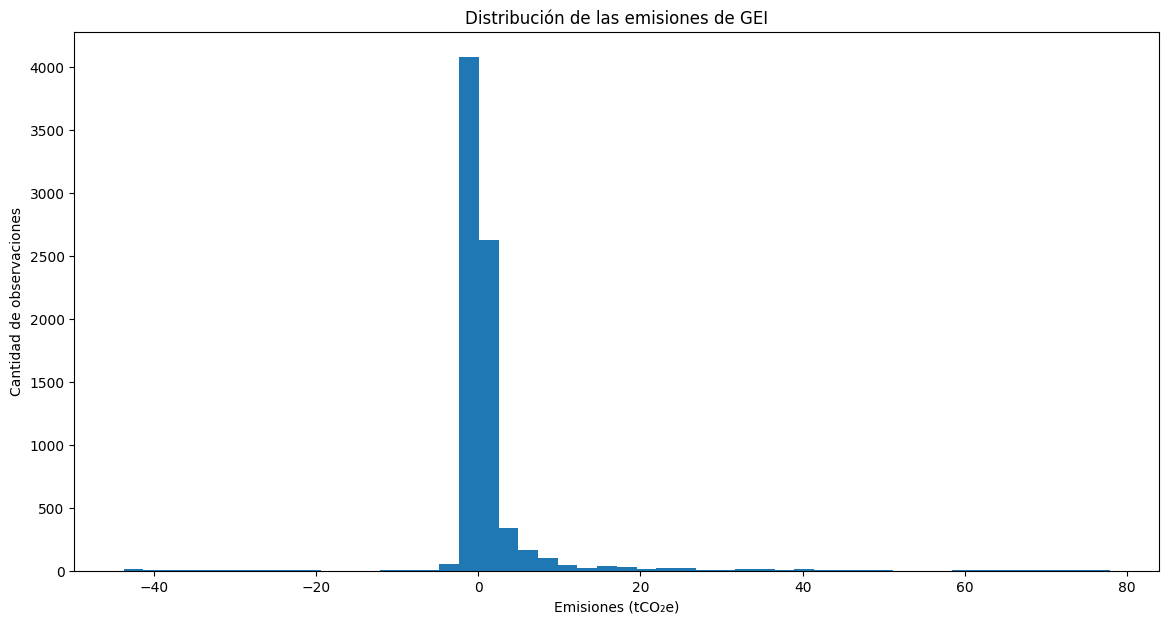

In [37]:
plt.figure(figsize=(14, 7))

plt.hist(
    df["valor_en_toneladas_de_co2e"],
    bins=50
)

plt.xlabel("Emisiones (tCO₂e)")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de las emisiones de GEI")

plt.show()

**Interpretación de la distribución de las emisiones**

La distribución de valor_en_toneladas_de_co2e presenta una marcada concentración de observaciones alrededor de cero y una asimetría hacia los valores positivos. Esto indica que la mayor parte de los registros corresponde a valores de emisiones relativamente bajos, mientras que una cantidad menor de observaciones presenta magnitudes considerablemente mayores.

Los valores negativos son menos frecuentes y pueden observarse principalmente en registros asociados al sector de Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra, particularmente en categorías relacionadas con tierras forestales. Estos valores son relevantes para el análisis porque pueden representar remociones de CO₂, es decir, procesos mediante los cuales se retira carbono de la atmósfera.

Por lo tanto, la distribución no debe analizarse únicamente desde la perspectiva de las emisiones positivas, sino considerando también la existencia de remociones y su posible contribución al balance total de gases de efecto invernadero.

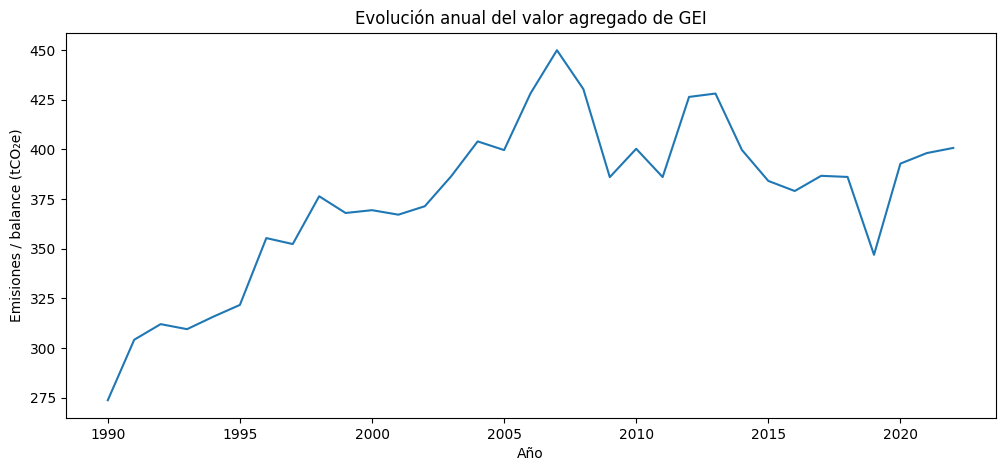

In [38]:
emisiones_por_año = (
    df.groupby("año")["valor_en_toneladas_de_co2e"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    emisiones_por_año["año"],
    emisiones_por_año["valor_en_toneladas_de_co2e"]
)

plt.xlabel("Año")
plt.ylabel("Emisiones / balance (tCO₂e)")
plt.title("Evolución anual del valor agregado de GEI")

plt.show()

**Interpretación de la evolución temporal**

La evolución anual del valor agregado de las emisiones muestra una tendencia general creciente durante el período 1990–2022, aunque se observan fluctuaciones entre determinados años.

El comportamiento de la serie indica que el valor agregado de los registros de emisiones y remociones no permaneció constante a lo largo del período. Se observa un incremento general desde comienzos de la década de 1990, alcanzándose valores elevados durante la segunda mitad de la década de 2000 y comienzos de la década de 2010.

Este comportamiento plantea nuevas preguntas para el análisis: ¿qué sectores explican esta tendencia?, ¿qué actividades presentan mayor crecimiento?, ¿qué gases tienen mayor participación y cómo evolucionó su contribución a lo largo del período?

Estas preguntas serán abordadas posteriormente mediante agregaciones por sector, actividad y tipo de gas.

In [39]:
# Separando emisiones de remociones:

#Emisiones positivas
emisiones_positivas = (
    df[df["valor_en_toneladas_de_co2e"] > 0]
    .groupby("año")["valor_en_toneladas_de_co2e"]
    .sum()
)

#Remociones
remociones = (
    df[df["valor_en_toneladas_de_co2e"] < 0]
    .groupby("año")["valor_en_toneladas_de_co2e"]
    .sum()
)

#Balance
balance = (
    df.groupby("año")["valor_en_toneladas_de_co2e"]
    .sum()
)

# Df final de emisiones, remociones y balance
df_em_rem = pd.concat(
    [emisiones_positivas,remociones,balance]
    ,axis=1
).reset_index()

### Normalización de variables categóricas

In [40]:
#Vemos cuantos valores tienen espacios externos

columnas_texto = [
    "sector",
    "actividad",
    "subactividad",
    "categoria",
   "id_ipcc",
    "tipo_de_gas",
    "tipo_de_registro"
]

for columna in columnas_texto:
    espacios = df[columna].astype(str).str.strip().ne(df[columna].astype(str)).sum()
    print(f"{columna}: {espacios} valores con espacios externos")

sector: 3232 valores con espacios externos
actividad: 4225 valores con espacios externos
subactividad: 4058 valores con espacios externos
categoria: 766 valores con espacios externos
id_ipcc: 0 valores con espacios externos
tipo_de_gas: 0 valores con espacios externos
tipo_de_registro: 0 valores con espacios externos


* Si no corregimos esto, significa que las mismas categorías pueden leerse como diferentes cuando intentemos hacer agrupaciones

In [41]:
# Por lo tanto aquí procedemos a limpiar los espacios externos para corregir las categorías y las mismas quedarían normalizadas (ejecutar nuevamente el código anterior para corroborar)

for columna in columnas_texto:
    df[columna] = df[columna].astype(str).str.strip()

In [42]:
# Corroboramos si encontramos valores vacíos dentro de las categorías

for columna in columnas_texto:
    vacios = df[columna].astype(str).str.strip().eq("").sum()
    print(f"{columna}: {vacios} valores vacíos")

sector: 0 valores vacíos
actividad: 0 valores vacíos
subactividad: 0 valores vacíos
categoria: 0 valores vacíos
id_ipcc: 0 valores vacíos
tipo_de_gas: 0 valores vacíos
tipo_de_registro: 0 valores vacíos


In [43]:
# Vemos la estructura del DataSet

for columna in columnas_texto:
    print(f"\n{columna}: {df[columna].nunique()} categorías únicas")


sector: 4 categorías únicas

actividad: 12 categorías únicas

subactividad: 32 categorías únicas

categoria: 68 categorías únicas

id_ipcc: 162 categorías únicas

tipo_de_gas: 5 categorías únicas

tipo_de_registro: 3 categorías únicas


* De esta forma empezamos a entender la jerarquía del dataset y posteriormente vamos a poder explorar esa estructura en SQL y Power BI

## Agregación por sector y evolución temporal

Hasta acá trabajamos principalmente con conteos de registros. A continuación agregamos los **valores** de `valor_en_toneladas_de_co2e` (no la cantidad de filas) para responder dos de las preguntas secundarias del proyecto: qué sectores concentran el mayor volumen de emisiones/remociones, y qué sectores crecieron o disminuyeron más entre 1990 y 2022.

In [44]:
totales_por_sector = (
    df.groupby("sector")["valor_en_toneladas_de_co2e"]
    .sum()
    .sort_values(ascending=False)
)

totales_por_sector

sector
Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra    5899.92
Energía                                                           5422.41
Residuos                                                           576.18
Procesos industriales y uso de productos                           499.82
Name: valor_en_toneladas_de_co2e, dtype: float64

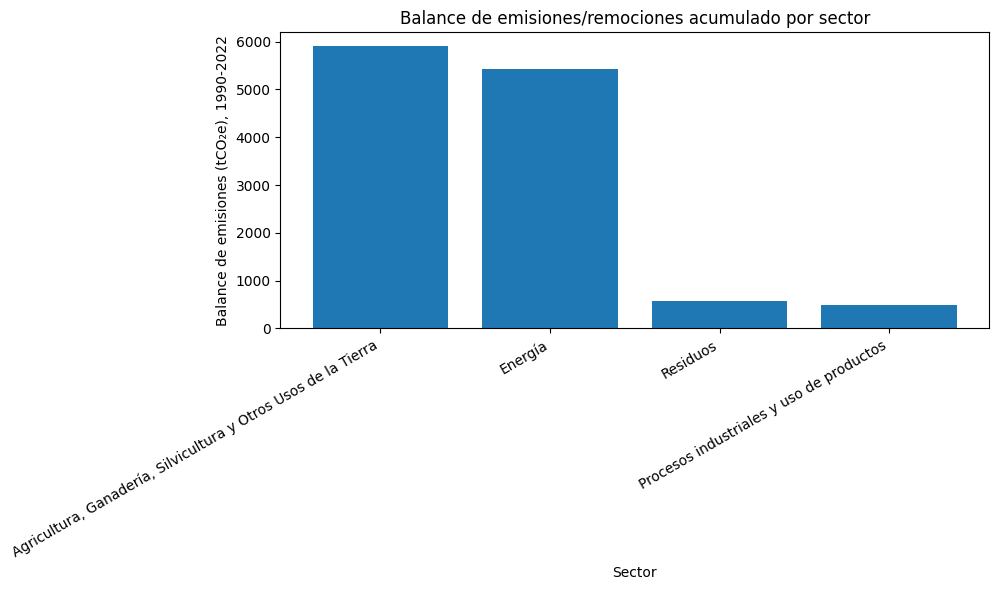

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    totales_por_sector.index,
    totales_por_sector.values
)

plt.xlabel("Sector")
plt.ylabel("Balance de emisiones (tCO₂e), 1990-2022")
plt.title("Balance de emisiones/remociones acumulado por sector")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

**Interpretación: totales por sector**

Agrupando por sector y sumando los valores (no solo contando registros), los dos sectores que concentran el mayor balance acumulado de emisiones/remociones entre 1990 y 2022 son "Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra" y "Energía", con valores acumulados bastante cercanos entre sí. Bastante más atrás quedan "Residuos" y "Procesos industriales y uso de productos".

Esto confirma parcialmente lo que habíamos visto antes con el registro individual de mayor valor (77.93 tCO₂e, en el sector Agricultura/Tierra): el sector con más peso en cantidad de observaciones extremas también es uno de los que más contribuye al balance total, aunque aquí aparece Energía muy cerca en el acumulado.

In [46]:
# Evolución anual del balance de emisiones/remociones, un valor por sector

pivot_sector_año = df.pivot_table(
    index="año",
    columns="sector",
    values="valor_en_toneladas_de_co2e",
    aggfunc="sum"
)

pivot_sector_año.head()

sector,"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",Energía,Procesos industriales y uso de productos,Residuos
año,,,,
1990,151.13,102.30,8.48,11.81
1991,176.17,108.01,7.87,12.13
1992,180.24,111.59,7.86,12.35
1993,174.97,113.60,8.35,12.59
1994,174.35,118.88,9.67,12.93


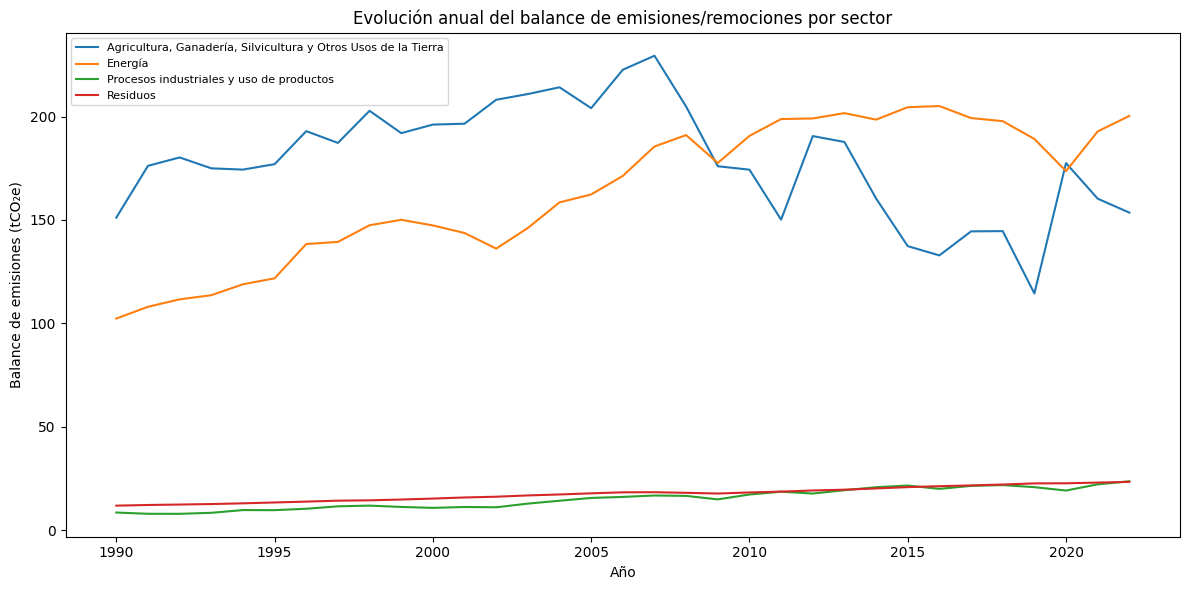

In [47]:
plt.figure(figsize=(12, 6))

for sector in pivot_sector_año.columns:
    plt.plot(
        pivot_sector_año.index,
        pivot_sector_año[sector],
        label=sector
    )

plt.xlabel("Año")
plt.ylabel("Balance de emisiones (tCO₂e)")
plt.title("Evolución anual del balance de emisiones/remociones por sector")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()

plt.show()

In [48]:
# Comparamos el valor de 1990 contra el de 2022 para cada sector, en términos absolutos y porcentuales
# (una comparación simple entre puntas; más adelante se puede refinar con promedios de varios años)

variacion_absoluta = (
    pivot_sector_año.loc[2022] - pivot_sector_año.loc[1990]
).sort_values(ascending=False)

variacion_pct = (
    (pivot_sector_año.loc[2022] - pivot_sector_año.loc[1990])
    / pivot_sector_año.loc[1990].abs() * 100
).sort_values(ascending=False)

variacion = pd.concat(
    [variacion_absoluta.rename("variacion_absoluta_tco2e"), variacion_pct.rename("variacion_pct")],
    axis=1
)

variacion

,variacion_absoluta_tco2e,variacion_pct
sector,,
Energía,98.02,95.816227
Procesos industriales y uso de productos,15.11,178.183962
Residuos,11.52,97.544454
"Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",2.42,1.601270


**Interpretación: evolución y variación por sector (1990 vs. 2022)**

En términos absolutos, "Energía" es el sector que más creció en el período (+98,0 tCO₂e entre puntas), seguido de lejos por "Procesos industriales y uso de productos" (+15,1) y "Residuos" (+11,5). "Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra" es el que menos varió en términos absolutos (+2,4), a pesar de ser el sector con mayor balance acumulado total — es decir, su magnitud es grande pero relativamente estable en el tiempo, con fluctuaciones año a año más que una tendencia sostenida de crecimiento.

En términos porcentuales el orden cambia: "Procesos industriales y uso de productos" es el que más creció relativamente (+178 %), seguido por "Residuos" (+98 %) y "Energía" (+96 %). Esto tiene sentido porque ese sector parte de una base mucho más chica en 1990, así que un mismo incremento absoluto representa una variación porcentual mucho mayor.

Esta comparación es un primer corte simple entre 1990 y 2022 (dos puntos), por lo que conviene tomarla como una aproximación: queda pendiente para una siguiente etapa comparar promedios de varios años en vez de años puntuales, para no depender de un valor atípico en el extremo de la serie.

## Composición por tipo de gas

Respondemos ahora dos preguntas secundarias que todavía estaban pendientes: qué gases tienen mayor participación en el balance total, y cómo cambió esa composición a lo largo del tiempo.

In [49]:
totales_por_gas = (
    df.groupby("tipo_de_gas")["valor_en_toneladas_de_co2e"]
    .sum()
    .sort_values(ascending=False)
)

participacion_por_gas = (totales_por_gas / totales_por_gas.sum() * 100).round(1)

pd.concat(
    [totales_por_gas.rename("total_tco2e"), participacion_por_gas.rename("participacion_%")],
    axis=1
)

,total_tco2e,participacion_%
tipo_de_gas,,
CO2,7475.36,60.3
CH4,4189.37,33.8
N2O,673.98,5.4
HFC,58.43,0.5
PFC,1.19,0.0


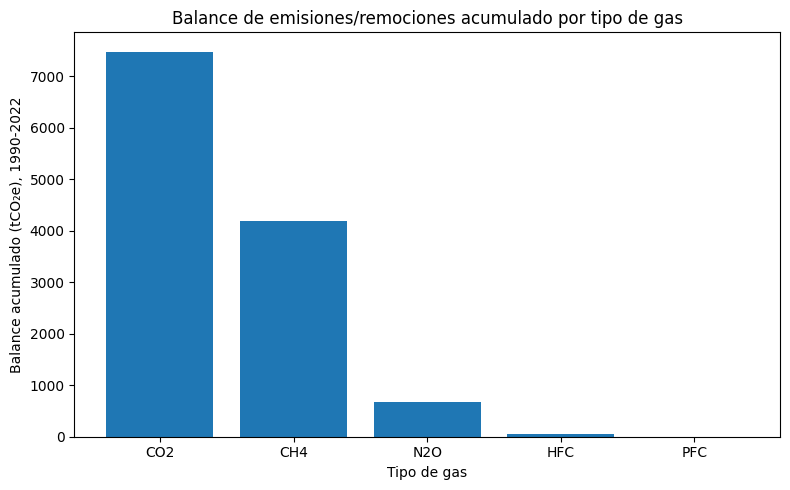

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(
    totales_por_gas.index,
    totales_por_gas.values
)

plt.xlabel("Tipo de gas")
plt.ylabel("Balance acumulado (tCO₂e), 1990-2022")
plt.title("Balance de emisiones/remociones acumulado por tipo de gas")
plt.tight_layout()

plt.show()

**Interpretación: participación por gas**

El CO₂ es, por lejos, el gas con mayor peso en el balance acumulado (60,3 %), seguido por el CH₄ (33,8 %) y el N₂O (5,4 %). Los HFC y PFC —gases sintéticos, típicos de procesos industriales— tienen una participación marginal (0,5 % y prácticamente 0 % respectivamente) en el acumulado de todo el período.

In [51]:
# Composición porcentual de cada gas dentro del balance total de cada año
# (participación relativa, no valores absolutos)

pivot_gas_año = df.pivot_table(
    index="año",
    columns="tipo_de_gas",
    values="valor_en_toneladas_de_co2e",
    aggfunc="sum"
).fillna(0)

composicion_gas_año = pivot_gas_año.div(pivot_gas_año.sum(axis=1), axis=0) * 100

composicion_gas_año.head()

tipo_de_gas,CH4,CO2,HFC,N2O,PFC
año,,,,,
1990,42.353500,51.757270,0.0,5.870963,0.018267
1991,38.855283,55.684134,0.0,5.444145,0.016438
1992,38.658505,55.954365,0.0,5.371106,0.016024
1993,40.192562,54.360118,0.0,5.431165,0.016155
1994,38.818352,56.001646,0.0,5.164171,0.015831


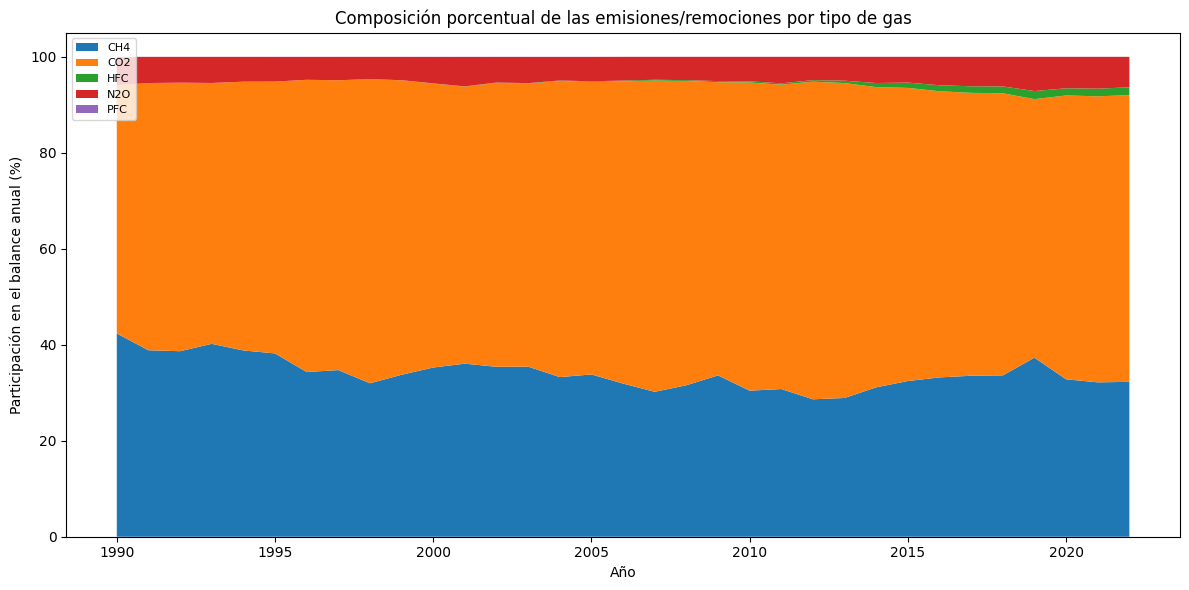

In [52]:
plt.figure(figsize=(12, 6))

plt.stackplot(
    composicion_gas_año.index,
    [composicion_gas_año[gas] for gas in composicion_gas_año.columns],
    labels=composicion_gas_año.columns
)

plt.xlabel("Año")
plt.ylabel("Participación en el balance anual (%)")
plt.title("Composición porcentual de las emisiones/remociones por tipo de gas")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()

plt.show()

**Interpretación: composición por gas a través del tiempo**

La composición sí cambió a lo largo del período: en 1990 el CO₂ representaba el 51,8 % del balance anual y el CH₄ el 42,4 %; para 2022 el CO₂ subió al 59,7 % y el CH₄ bajó al 32,3 %. El N₂O se mantuvo relativamente estable, entre 5 % y 6 % en ambas puntas. Los HFC, que no existían en el balance de 1990 (0 %), alcanzan un 1,6 % en 2022 — coherente con que son gases sintéticos de uso industrial que se fueron incorporando en las últimas décadas.

## Principales actividades dentro de los sectores con mayor contribución

Ya vimos que Energía y Agricultura/Ganadería/Silvicultura son los dos sectores con mayor balance acumulado. Ahora abrimos cada uno por actividad para responder qué actividades explican las emisiones dentro de cada sector.

In [53]:
sectores_principales = [
    "Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra",
    "Energía"
]

actividades_por_sector = {}

for sector in sectores_principales:
    actividades_por_sector[sector] = (
        df[df["sector"] == sector]
        .groupby("actividad")["valor_en_toneladas_de_co2e"]
        .sum()
        .sort_values(ascending=False)
    )
    print(f"\n{sector}:\n{actividades_por_sector[sector]}")


Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra:
actividad
Ganadería        2701.09
Tierra           2368.58
Uso de Suelos     830.25
Name: valor_en_toneladas_de_co2e, dtype: float64

Energía:
actividad
Actividades de quema de combustible                                   4669.41
Emisiones fugitivas provenientes de la fabricación de combustibles     753.00
Name: valor_en_toneladas_de_co2e, dtype: float64


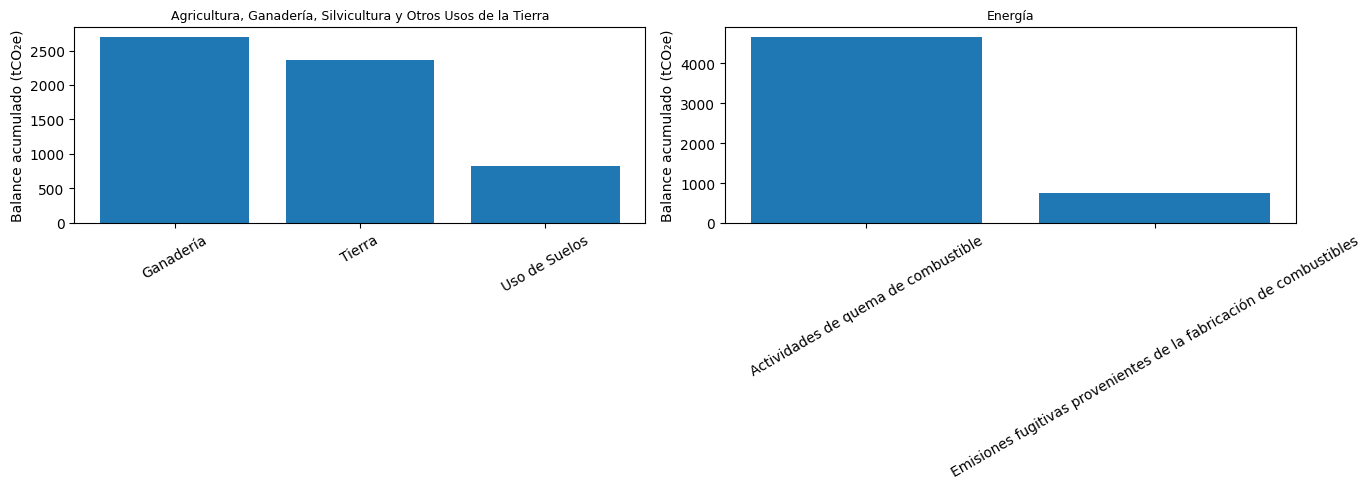

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sector in zip(axes, sectores_principales):
    datos = actividades_por_sector[sector]
    ax.bar(datos.index, datos.values)
    ax.set_title(sector, fontsize=9)
    ax.set_ylabel("Balance acumulado (tCO₂e)")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Interpretación: actividades dentro de los sectores principales**

Dentro de Agricultura/Ganadería/Silvicultura, la actividad "Ganadería" es la que más aporta (2.701,09 tCO₂e acumuladas), seguida de cerca por "Tierra" (2.368,58) y, más atrás, "Uso de Suelos" (830,25). Es decir que el peso de este sector se reparte entre la producción ganadera y los cambios de uso de la tierra (que incluyen tanto emisiones como remociones, como vimos antes).

Dentro de Energía, en cambio, el peso está mucho más concentrado: "Actividades de quema de combustible" explica 4.669,41 tCO₂e, muy por encima de "Emisiones fugitivas provenientes de la fabricación de combustibles" (753,00). Esto confirma que, dentro del sector energético, la combustión (transporte, generación eléctrica, industria) es la actividad que realmente explica el peso del sector.

## Principales categorías emisoras en los últimos años

Por último, respondemos la pregunta sobre las principales fuentes de emisiones en los años más recientes, mirando el nivel de categoría (el más granular del dataset) para el período 2018-2022.

In [55]:
ultimos_5_años = df[df["año"] >= 2018]

top_categorias_recientes = (
    ultimos_5_años
    .groupby("categoria")["valor_en_toneladas_de_co2e"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categorias_recientes

categoria
Bovinos de Carne                                                      361.49
Transporte terrestre por carretera                                    225.97
Producción pública de electricidad y calor                            196.20
Tierras forestales convertidas en pastizales                          172.58
Residencial                                                           121.01
Tierras forestales convertidas en Tierras de cultivo                  109.02
Fugitivas producción de Gas Natural                                   100.72
Industria no especificada:                                             53.84
Fabricación de combustibles sólidos y otras industrias energéticas     53.68
Bovinos Lecheros                                                       45.32
Name: valor_en_toneladas_de_co2e, dtype: float64

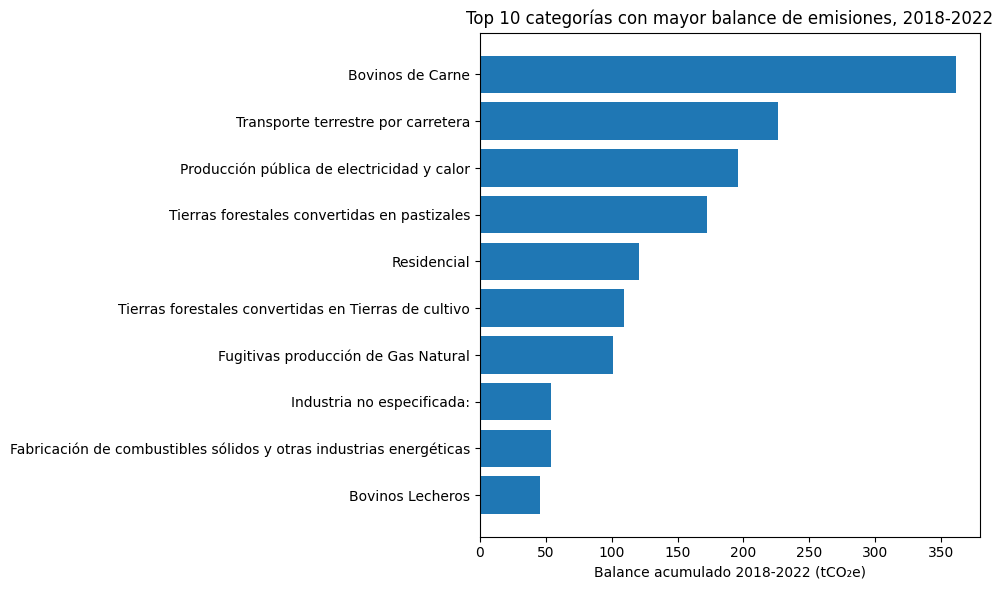

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_categorias_recientes.index[::-1],
    top_categorias_recientes.values[::-1]
)

plt.xlabel("Balance acumulado 2018-2022 (tCO₂e)")
plt.title("Top 10 categorías con mayor balance de emisiones, 2018-2022")
plt.tight_layout()

plt.show()

**Interpretación: categorías recientes**

En el período 2018-2022, "Bovinos de Carne" es la categoría individual con mayor balance acumulado (361,49 tCO₂e), seguida por "Transporte terrestre por carretera" (225,97) y "Producción pública de electricidad y calor" (196,20). También aparecen entre las principales dos categorías de cambio de uso de la tierra ("Tierras forestales convertidas en pastizales" y "...en Tierras de cultivo"), lo que confirma que, incluso mirando solo los últimos años, la ganadería, el transporte, la generación eléctrica y el cambio de uso de la tierra siguen siendo los focos más relevantes desde una perspectiva de gestión ambiental.

## Conclusiones generales

Retomando la pregunta principal (¿cómo evolucionaron las emisiones de GEI de Argentina entre 1990 y 2022 y qué sectores y actividades explican los principales cambios?):

* El balance total de GEI creció de forma sostenida entre 1990 y 2022, con fluctuaciones interanuales, y sin una única causa: **Energía** explica la mayor parte del crecimiento en términos absolutos (a través de la quema de combustibles — transporte, generación eléctrica, industria), mientras que **Agricultura, Ganadería, Silvicultura y Otros Usos de la Tierra** es el sector de mayor volumen acumulado pero se mantuvo relativamente estable, con la ganadería y los cambios de uso de la tierra como sus componentes principales.
* La composición por gas también cambió: el CO₂ ganó peso relativo frente al CH₄ a lo largo del período, y los gases sintéticos (HFC) aparecen recién en las últimas décadas, asociados a procesos industriales.
* Los valores negativos del dataset no son errores sino remociones de CO₂ por uso de la tierra, y quedaron diferenciados en la variable `tipo_de_registro` para poder calcular emisiones brutas, remociones y balance neto en las siguientes etapas.
* Desde una perspectiva de gestión ambiental, los focos de intervención más relevantes —tanto por su peso histórico como por su vigencia en los últimos 5 años— son: la ganadería (fermentación entérica y gestión de estiércol), la quema de combustibles fósiles (transporte y generación eléctrica) y los cambios de uso de la tierra (deforestación/conversión de tierras forestales).

Con esto quedan respondidas las nueve preguntas secundarias planteadas al inicio del notebook. El dataset limpio, con las variables `tipo_de_registro` incorporada y los textos normalizados, queda listo para la siguiente etapa: carga en SQL y construcción del dashboard en Power BI.

## Exportación del dataset limpio

Recién acá, al final del proceso de auditoría, limpieza y exploración, exportamos el dataset a `data/processed/`. De esta forma el archivo `_coma` contiene la versión final ya sin duplicados exactos, con la variable `tipo_de_registro` incorporada y con las columnas de texto normalizadas — listo para cargarlo en SQL y Power BI en la siguiente etapa del proyecto.

In [57]:
df.to_csv(
    "E:\\PROYECTOS PYTHON\\proyecto-GEI\\data\\processed\\emisiones_datos_totales_1990_2022_coma.csv",
    sep=",", index=False)